# MJWARP-Render Benchmark Visualization

This notebook visualizes the results of the grid search benchmark for mjwarp-render performance.

The benchmark varies:
- `nworld`: number of parallel worlds (1, 2, 4, ..., 8192)
- `resolution`: image width/height in pixels (16, 32, 64, ..., 512)

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load Benchmark Results

In [3]:
# Load the benchmark results JSON file
results_path = Path("../bowl_results.json")

# You can change this to your results file path
# results_path = Path("/path/to/your/benchmark_results.json")

with open(results_path) as f:
    data = json.load(f)

print(f"Loaded results from: {results_path}")
print(f"Model: {data['metadata']['model_path']}")
print(f"Timestamp: {data['metadata']['timestamp']}")
print(f"nworld values: {data['metadata']['nworld_values']}")
print(f"Resolution values: {data['metadata']['resolution_values']}")

Loaded results from: ../bowl_results.json
Model: None
Timestamp: 2025-12-14T15:46:57.742551
nworld values: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
Resolution values: [16, 32, 64, 128, 256, 512]


In [4]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(data["benchmarks"])

# Add derived columns
df["total_pixels"] = df["resolution"] ** 2 * df["nworld"]
df["resolution_str"] = df["resolution"].astype(str) + "x" + df["resolution"].astype(str)

print(f"Total benchmark runs: {len(df)}")
print(f"Successful runs: {df['success'].sum()}")
print(f"Failed runs: {(~df['success']).sum()}")

df.head(10)

Total benchmark runs: 84
Successful runs: 76
Failed runs: 8


,nworld,resolution,benchmark_frames,warmup_frames,success,error,images_per_second,throughput_fps,avg_fps,avg_time_ms,avg_time_per_image_ms,total_time_s,total_pixels,resolution_str
0,1,16,100.0,10.0,True,None,72.29,72.29,72.29,13.833,13.833,1.383,256,16x16
1,2,16,100.0,10.0,True,None,147.81,73.90,73.90,13.531,6.766,1.353,512,16x16
2,4,16,100.0,10.0,True,None,297.42,74.35,74.35,13.449,3.362,1.345,1024,16x16
3,8,16,100.0,10.0,True,None,597.22,74.65,74.65,13.395,1.674,1.340,2048,16x16
4,16,16,100.0,10.0,True,None,1168.79,73.05,73.05,13.689,0.856,1.369,4096,16x16
5,32,16,100.0,10.0,True,None,2313.56,72.30,72.30,13.831,0.432,1.383,8192,16x16
6,64,16,100.0,10.0,True,None,4540.30,70.94,70.94,14.096,0.220,1.410,16384,16x16
7,128,16,100.0,10.0,True,None,8663.57,67.68,67.68,14.775,0.115,1.477,32768,16x16
8,256,16,100.0,10.0,True,None,15703.59,61.34,61.34,16.302,0.064,1.630,65536,16x16
9,512,16,100.0,10.0,True,None,26363.64,51.49,51.49,19.421,0.038,1.942,131072,16x16


## Create Pivot Tables for Heatmaps

In [5]:
# Filter successful runs only
df_success = df[df["success"] == True].copy()

# Create pivot table for images per second
pivot_ips = df_success.pivot_table(
    values="images_per_second", index="resolution", columns="nworld", aggfunc="mean"
)

# Create pivot table for throughput FPS
pivot_fps = df_success.pivot_table(
    values="throughput_fps", index="resolution", columns="nworld", aggfunc="mean"
)

# Create pivot table for avg time per image
pivot_time = df_success.pivot_table(
    values="avg_time_per_image_ms", index="resolution", columns="nworld", aggfunc="mean"
)

print("Images per second pivot table:")
pivot_ips

Images per second pivot table:


nworld,1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192
resolution,,,,,,,,,,,,,,
16,72.29,147.81,297.42,597.22,1168.79,2313.56,4540.30,8663.57,15703.59,26363.64,41044.97,56025.99,68453.38,76675.12
32,74.18,149.72,295.61,588.37,1157.18,2228.43,4157.81,7364.65,12054.52,17586.92,22575.66,26518.55,28922.15,30166.86
64,73.99,147.10,290.36,563.35,1068.89,1950.21,3276.80,5006.70,6788.09,8228.06,9141.11,9630.62,9889.45,9987.82
128,72.86,143.21,270.37,497.79,838.05,1300.53,1785.31,2190.96,2459.70,2602.23,2667.98,2703.98,2728.66,NaN
256,68.17,126.31,215.98,338.98,469.71,584.77,662.65,704.84,727.81,736.42,739.96,NaN,NaN,NaN
512,57.36,93.43,135.65,174.26,202.40,219.88,228.11,232.22,232.14,235.74,NaN,NaN,NaN,NaN


## Heatmap: Images per Second

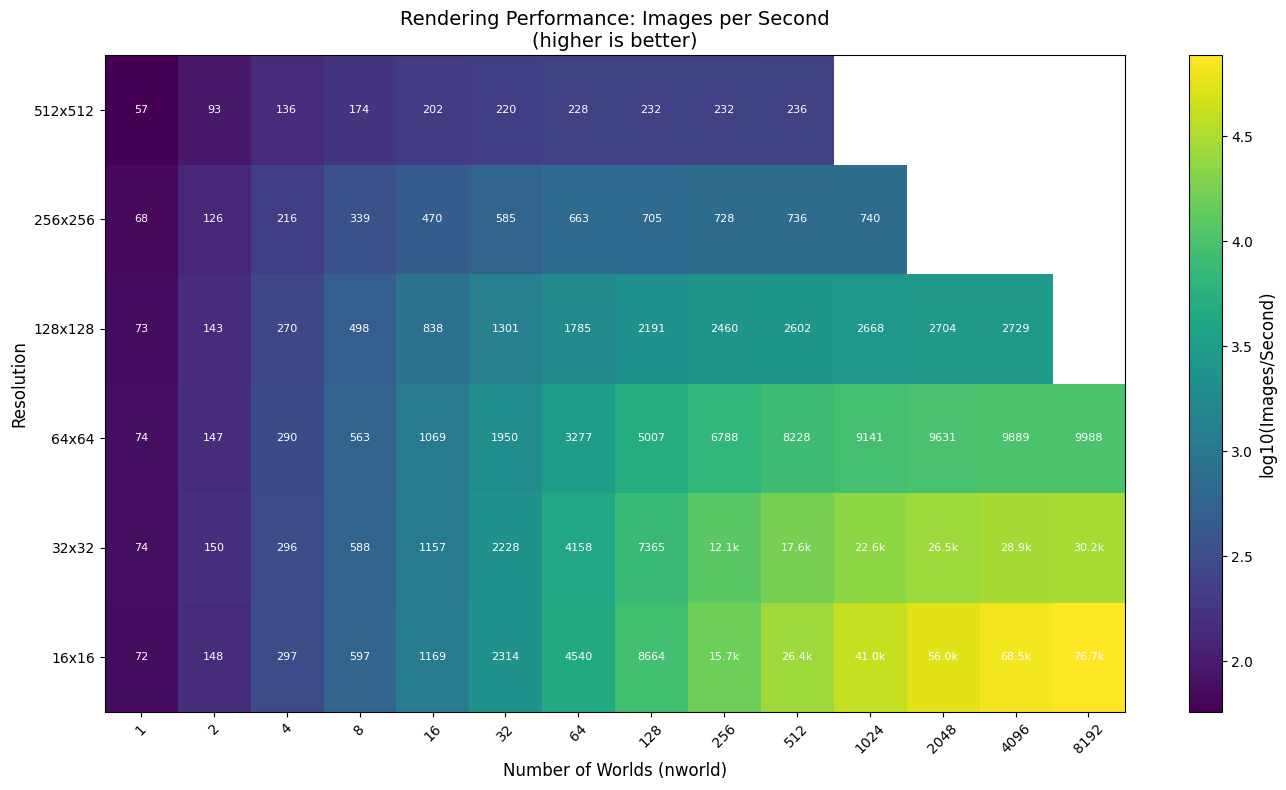

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

# Use log scale for color since values span orders of magnitude
im = ax.imshow(
    np.log10(pivot_ips.values), cmap="viridis", aspect="auto", origin="lower"
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(Images/Second)", fontsize=12)

# Set tick labels
ax.set_xticks(range(len(pivot_ips.columns)))
ax.set_xticklabels(pivot_ips.columns, rotation=45)
ax.set_yticks(range(len(pivot_ips.index)))
ax.set_yticklabels([f"{r}x{r}" for r in pivot_ips.index])

# Add value annotations
for i in range(len(pivot_ips.index)):
    for j in range(len(pivot_ips.columns)):
        val = pivot_ips.values[i, j]
        if not np.isnan(val):
            text = f"{val:.0f}" if val < 10000 else f"{val/1000:.1f}k"
            ax.text(j, i, text, ha="center", va="center", fontsize=8, color="white")

ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
ax.set_ylabel("Resolution", fontsize=12)
ax.set_title(
    "Rendering Performance: Images per Second\n(higher is better)", fontsize=14
)

plt.tight_layout()
plt.savefig("benchmark_heatmap_ips.png", dpi=150)
plt.show()

## Heatmap: Throughput FPS (Batched Frames)

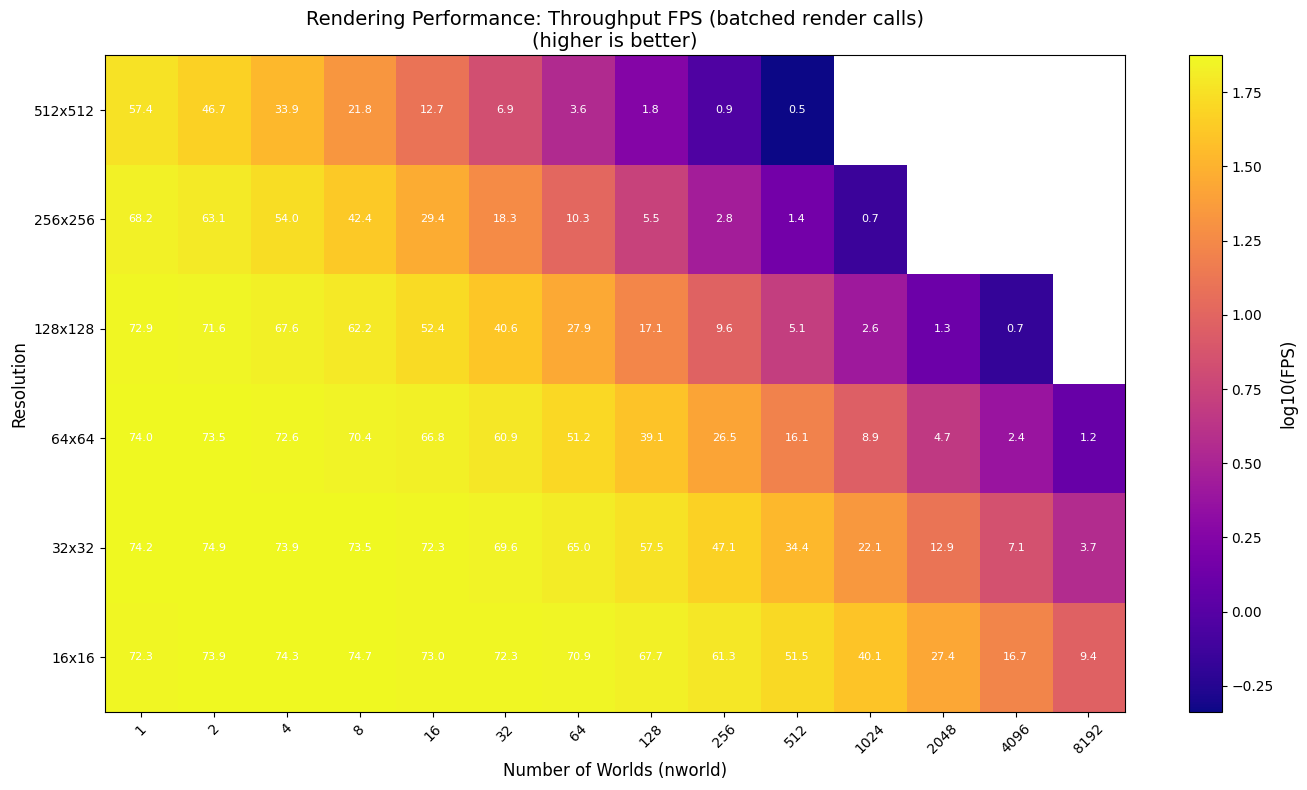

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(np.log10(pivot_fps.values), cmap="plasma", aspect="auto", origin="lower")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(FPS)", fontsize=12)

ax.set_xticks(range(len(pivot_fps.columns)))
ax.set_xticklabels(pivot_fps.columns, rotation=45)
ax.set_yticks(range(len(pivot_fps.index)))
ax.set_yticklabels([f"{r}x{r}" for r in pivot_fps.index])

for i in range(len(pivot_fps.index)):
    for j in range(len(pivot_fps.columns)):
        val = pivot_fps.values[i, j]
        if not np.isnan(val):
            text = f"{val:.1f}" if val < 100 else f"{val:.0f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=8, color="white")

ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
ax.set_ylabel("Resolution", fontsize=12)
ax.set_title(
    "Rendering Performance: Throughput FPS (batched render calls)\n(higher is better)",
    fontsize=14,
)

plt.tight_layout()
plt.savefig("benchmark_heatmap_fps.png", dpi=150)
plt.show()

## Line Plot: Images/Second vs nworld (by Resolution)

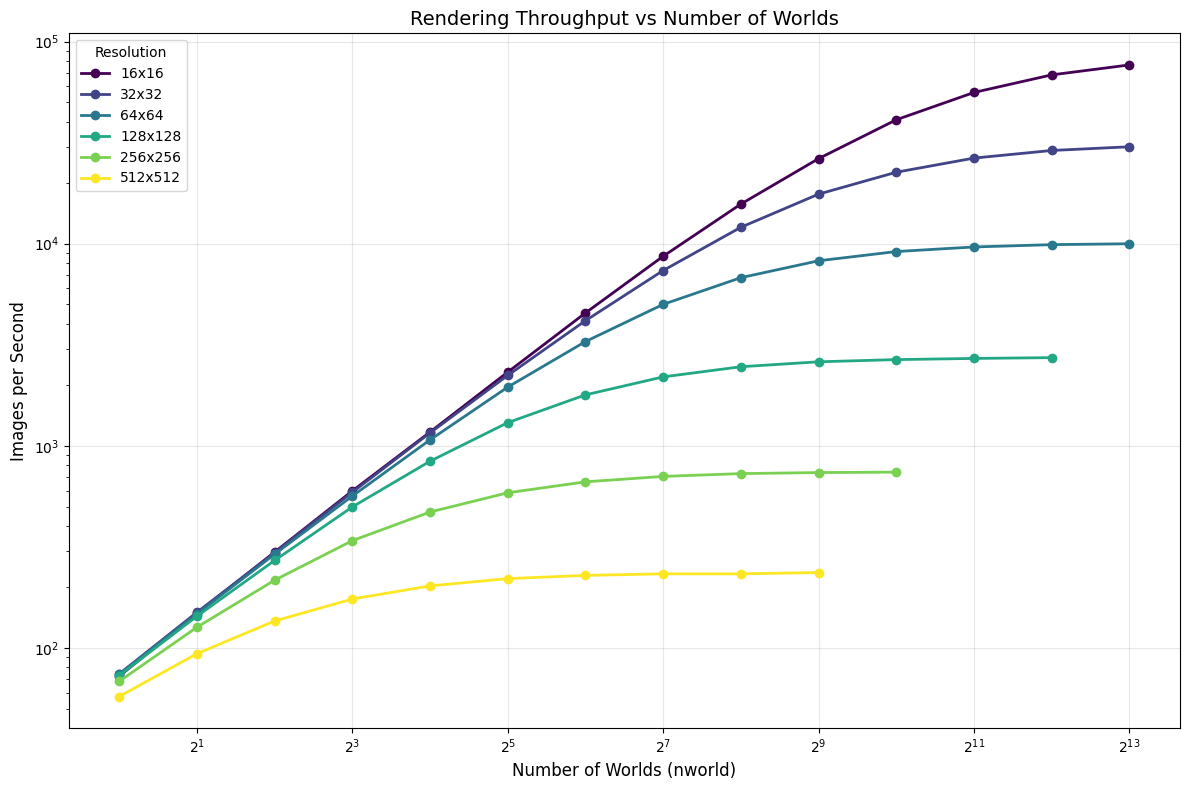

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_ips.index)))

for idx, (resolution, color) in enumerate(zip(pivot_ips.index, colors)):
    row = pivot_ips.loc[resolution]
    valid = ~row.isna()
    ax.plot(
        row.index[valid],
        row.values[valid],
        marker="o",
        linewidth=2,
        markersize=6,
        color=color,
        label=f"{resolution}x{resolution}",
    )

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
ax.set_ylabel("Images per Second", fontsize=12)
ax.set_title("Rendering Throughput vs Number of Worlds", fontsize=14)
ax.legend(title="Resolution", loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_lineplot_ips_vs_nworld.png", dpi=150)
plt.show()

## Line Plot: Images/Second vs Resolution (by nworld)

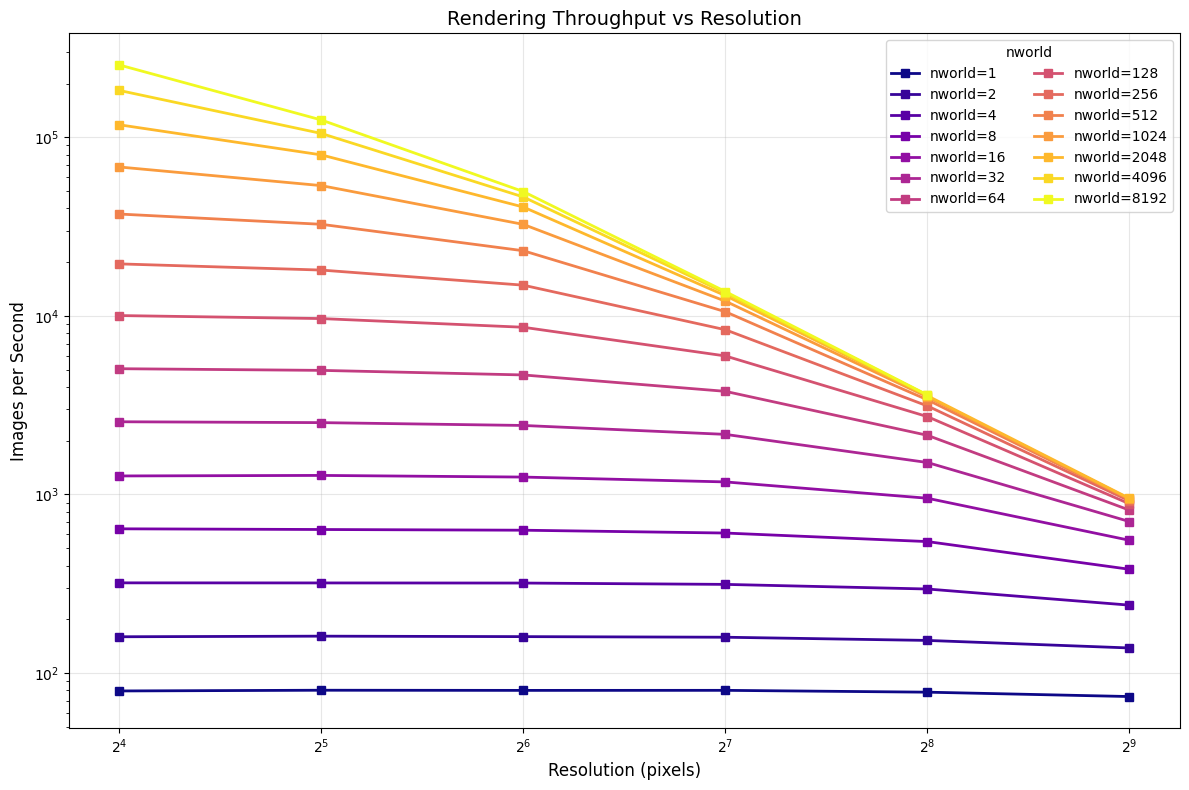

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.plasma(np.linspace(0, 1, len(pivot_ips.columns)))

for idx, (nworld, color) in enumerate(zip(pivot_ips.columns, colors)):
    col = pivot_ips[nworld]
    valid = ~col.isna()
    ax.plot(
        col.index[valid],
        col.values[valid],
        marker="s",
        linewidth=2,
        markersize=6,
        color=color,
        label=f"nworld={nworld}",
    )

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Resolution (pixels)", fontsize=12)
ax.set_ylabel("Images per Second", fontsize=12)
ax.set_title("Rendering Throughput vs Resolution", fontsize=14)
ax.legend(title="nworld", loc="best", ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_lineplot_ips_vs_resolution.png", dpi=150)
plt.show()

## Scaling Efficiency Analysis

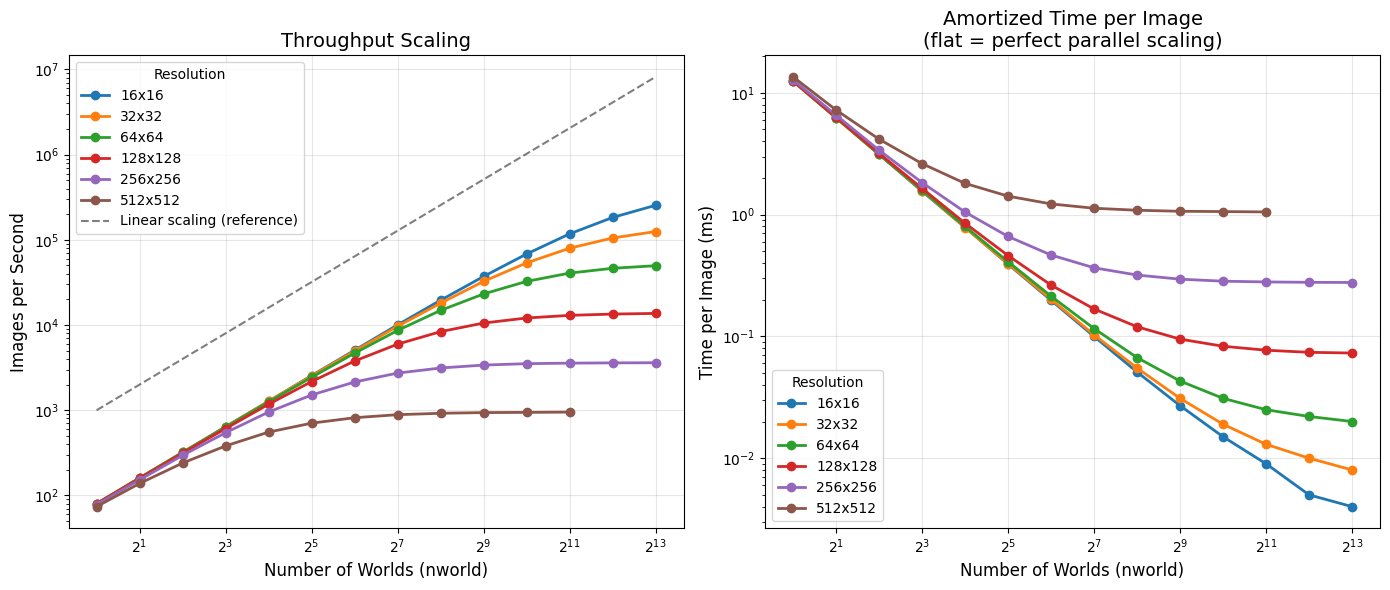

In [10]:
# Calculate scaling efficiency: how much does throughput increase with nworld?
# Perfect scaling would be linear (doubling nworld doubles throughput)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Actual images/sec vs ideal linear scaling
ax = axes[0]
for resolution in pivot_ips.index:
    row = pivot_ips.loc[resolution]
    valid = ~row.isna()
    if valid.sum() > 0:
        base_val = row[valid].iloc[0]  # Value at smallest nworld
        base_nworld = row.index[valid][0]
        ax.plot(
            row.index[valid],
            row.values[valid],
            marker="o",
            linewidth=2,
            label=f"{resolution}x{resolution}",
        )

# Add ideal linear scaling reference line
nworld_range = np.array([1, 8192])
ax.plot(
    nworld_range,
    nworld_range * 1000,
    "k--",
    alpha=0.5,
    label="Linear scaling (reference)",
)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
ax.set_ylabel("Images per Second", fontsize=12)
ax.set_title("Throughput Scaling", fontsize=14)
ax.legend(title="Resolution", loc="best")
ax.grid(True, alpha=0.3)

# Right: Time per image vs nworld (should be flat for perfect scaling)
ax = axes[1]
for resolution in pivot_time.index:
    row = pivot_time.loc[resolution]
    valid = ~row.isna()
    if valid.sum() > 0:
        ax.plot(
            row.index[valid],
            row.values[valid],
            marker="o",
            linewidth=2,
            label=f"{resolution}x{resolution}",
        )

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
ax.set_ylabel("Time per Image (ms)", fontsize=12)
ax.set_title("Amortized Time per Image\n(flat = perfect parallel scaling)", fontsize=14)
ax.legend(title="Resolution", loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_scaling_analysis.png", dpi=150)
plt.show()

## Failure Analysis

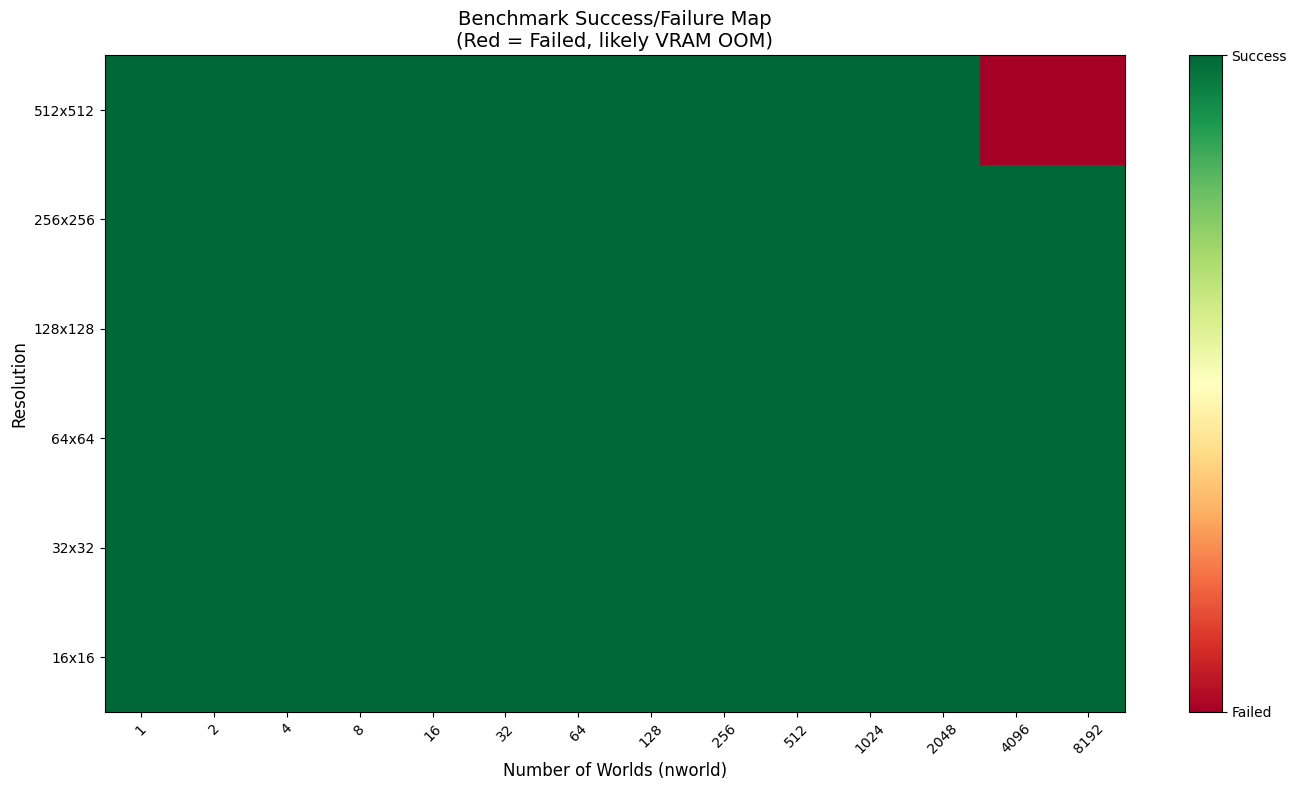


Failure summary by error type:
error
VRAM_OOM       1
Skipped_OOM    1
Name: count, dtype: int64


In [11]:
# Show which configurations failed (likely due to VRAM limits)
df_failed = df[df["success"] == False].copy()

if len(df_failed) > 0:
    # Create a matrix showing success/failure
    success_matrix = df.pivot_table(
        values="success", index="resolution", columns="nworld", aggfunc="first"
    ).astype(float)

    fig, ax = plt.subplots(figsize=(14, 8))

    im = ax.imshow(
        success_matrix.values,
        cmap="RdYlGn",
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_ticklabels(["Failed", "Success"])

    ax.set_xticks(range(len(success_matrix.columns)))
    ax.set_xticklabels(success_matrix.columns, rotation=45)
    ax.set_yticks(range(len(success_matrix.index)))
    ax.set_yticklabels([f"{r}x{r}" for r in success_matrix.index])

    ax.set_xlabel("Number of Worlds (nworld)", fontsize=12)
    ax.set_ylabel("Resolution", fontsize=12)
    ax.set_title(
        "Benchmark Success/Failure Map\n(Red = Failed, likely VRAM OOM)", fontsize=14
    )

    plt.tight_layout()
    plt.savefig("benchmark_failure_map.png", dpi=150)
    plt.show()

    print("\nFailure summary by error type:")
    print(df_failed["error"].value_counts())
else:
    print("All benchmarks succeeded!")

## Summary Statistics

In [12]:
print("=" * 60)
print("BENCHMARK SUMMARY")
print("=" * 60)

if len(df_success) > 0:
    print(f"\nBest images/second: {df_success['images_per_second'].max():.2f}")
    best_idx = df_success["images_per_second"].idxmax()
    best = df_success.loc[best_idx]
    print(
        f"  at nworld={best['nworld']}, resolution={best['resolution']}x{best['resolution']}"
    )

    print(f"\nBest throughput FPS: {df_success['throughput_fps'].max():.2f}")
    best_idx = df_success["throughput_fps"].idxmax()
    best = df_success.loc[best_idx]
    print(
        f"  at nworld={best['nworld']}, resolution={best['resolution']}x{best['resolution']}"
    )

    print(
        f"\nLowest time per image: {df_success['avg_time_per_image_ms'].min():.4f} ms"
    )
    best_idx = df_success["avg_time_per_image_ms"].idxmin()
    best = df_success.loc[best_idx]
    print(
        f"  at nworld={best['nworld']}, resolution={best['resolution']}x{best['resolution']}"
    )

print("\n" + "=" * 60)

BENCHMARK SUMMARY

Best images/second: 254385.97
  at nworld=8192, resolution=16x16

Best throughput FPS: 80.48
  at nworld=2, resolution=32x32

Lowest time per image: 0.0040 ms
  at nworld=8192, resolution=16x16



## Export Summary Table

In [13]:
# Export the pivot table as CSV for reference
pivot_ips.to_csv("benchmark_summary_images_per_second.csv")
pivot_fps.to_csv("benchmark_summary_throughput_fps.csv")
pivot_time.to_csv("benchmark_summary_time_per_image_ms.csv")

print("Exported summary CSV files:")
print("  - benchmark_summary_images_per_second.csv")
print("  - benchmark_summary_throughput_fps.csv")
print("  - benchmark_summary_time_per_image_ms.csv")

Exported summary CSV files:
  - benchmark_summary_images_per_second.csv
  - benchmark_summary_throughput_fps.csv
  - benchmark_summary_time_per_image_ms.csv
